<a href="https://colab.research.google.com/github/Feranmi149/OIBSIP/blob/main/TASK_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.shape

(1000, 9)

In [ ]:
import pandas as pd
df = pd.read_csv('retail_sales_dataset.csv')

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df = pd.read_csv('retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [ ]:
monthly_sales = df['Total Amount'].resample('ME').sum()

In [ ]:
quarterly_sales = df['Total Amount'].resample('QE').sum()

In [ ]:
print("Peak month:", monthly_sales.idxmax(), "-", monthly_sales.max())

Peak month: 2023-05-31 00:00:00 - 53150


In [ ]:
print("Lowest month:", monthly_sales.idxmin(), "-", monthly_sales.min())

Lowest month: 2024-01-31 00:00:00 - 1530


Sales peaked in may 2023 at ₦53,150, possibly linked to a seasonal promotion. Then lowest sales occured in january 2024 at ₦1,530, suggesting a slow period worth investigating further.

<Axes: title={'center': 'Customer Gender Breakdown'}, xlabel='Gender'>

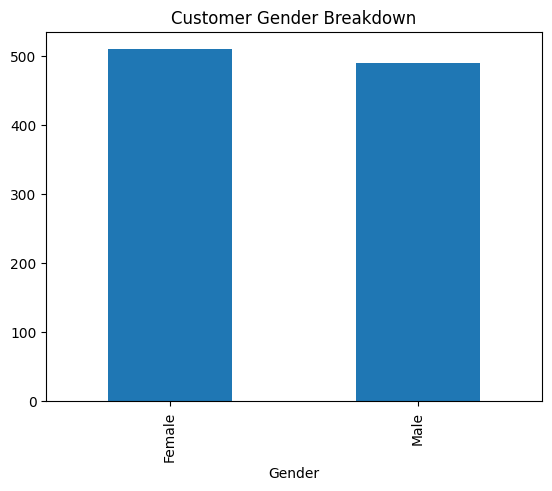

In [ ]:
df['Gender'].value_counts().plot(kind='bar', title='Customer Gender Breakdown')

<Axes: title={'center': 'Customer Age Distribution'}, ylabel='Frequency'>

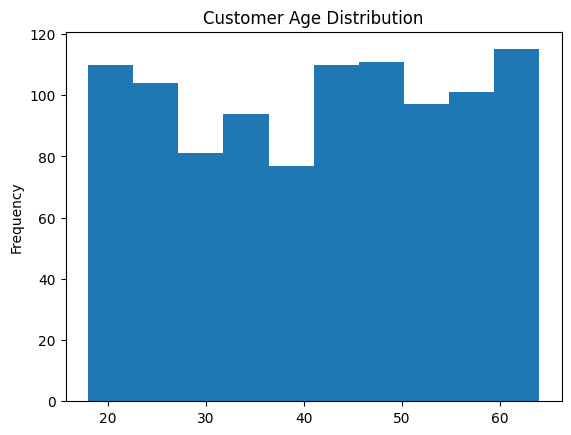

In [ ]:
df['Age'].plot(kind='hist', bins=10, title='Customer Age Distribution')

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

In [ ]:
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

In [ ]:
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

<Axes: title={'center': 'Customer Age Group Distribution'}, xlabel='Age Group'>

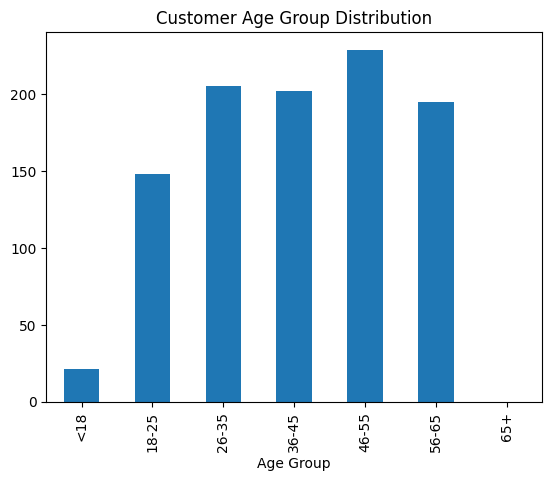

In [ ]:
df['Age Group'].value_counts().sort_index().plot(kind='bar', title='Customer Age Group Distribution')

The majority of customers fall within the 46-55 age group, followed closely by 26-35 and 36-45. Very few customers are under 18 or over 65, suggesting the core customer base is working-age adults rather than teens or seniors


<Axes: title={'center': 'Customer Gender Breakdown'}, xlabel='Gender'>

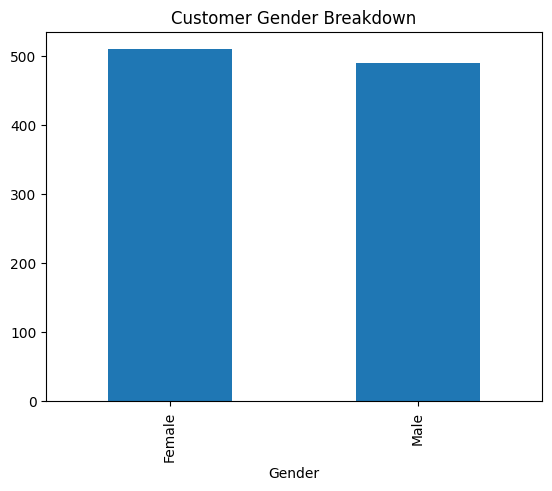

In [ ]:
df['Gender'].value_counts().plot(kind='bar', title='Customer Gender Breakdown')

The customer base is fairly evenly split by gender, with Female customers slightly outnumbering Male customers. This suggests marketing efforts shouldn't heavily favor one gender over the other, though slight variations could be explored by product category.

In [ ]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Product Category'>

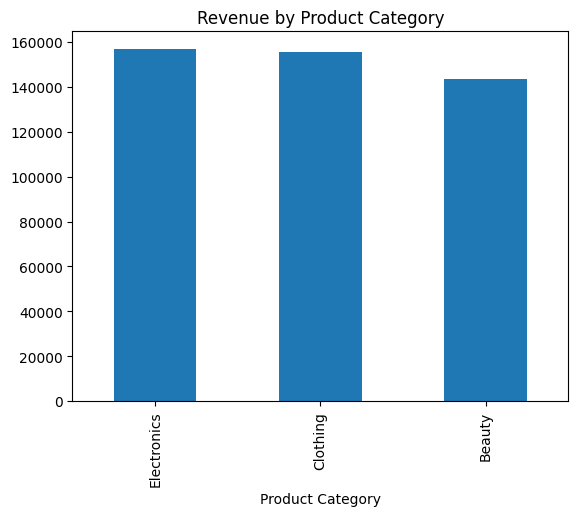

In [ ]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).plot(kind='bar', title='Revenue by Product Category')

Electronics generates the highest revenue, closely followed by Clothing, with Beauty slightly behind. The relatively even spread across all three categories suggests a balanced customer interest rather than dependence on a single product line, though Electronics could be prioritized slightly more in stocking and promotions given its lead.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(8,6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: >

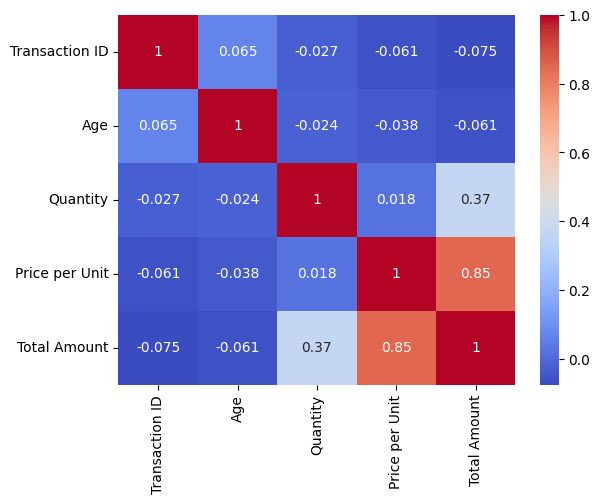

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')


Text(0.5, 1.0, 'Correlation Heatmap')

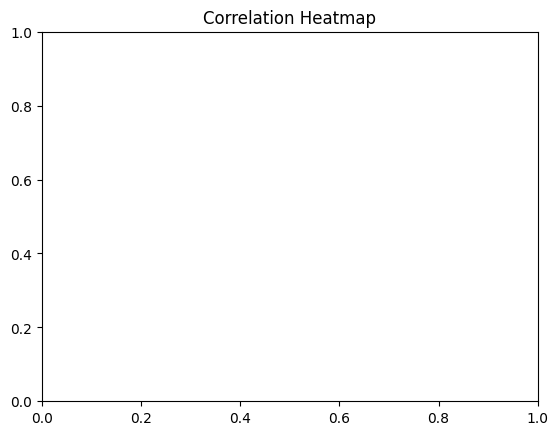

In [ ]:
plt.title('Correlation Heatmap')


In [ ]:
plt.show()

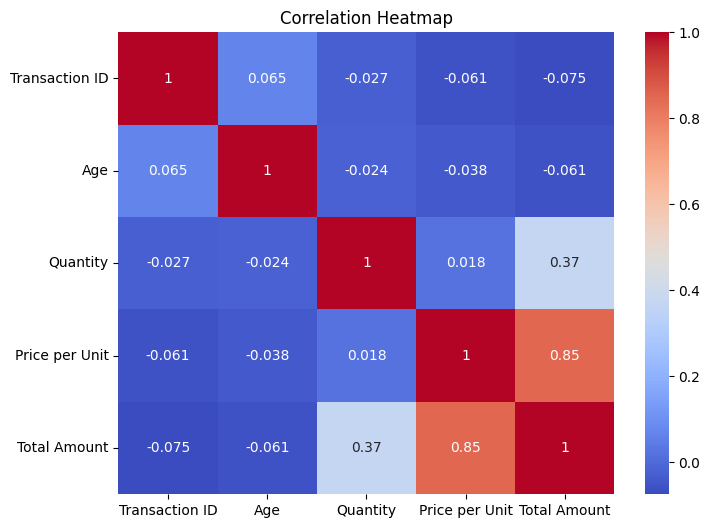

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Total Amount is most strongly correlated with Price per Unit (0.85), and moderately correlated with Quantity (0.37)  both expected, since revenue is a direct product of price and quantity. Age shows almost no correlation with Total Amount (-0.06), indicating that customer age has little to no influence on how much a customer spends per transaction

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

/tmp/ipykernel_646/2833178493.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spend = df.groupby(['Age Group', 'Gender'])['Total Amount'].mean().unstack()


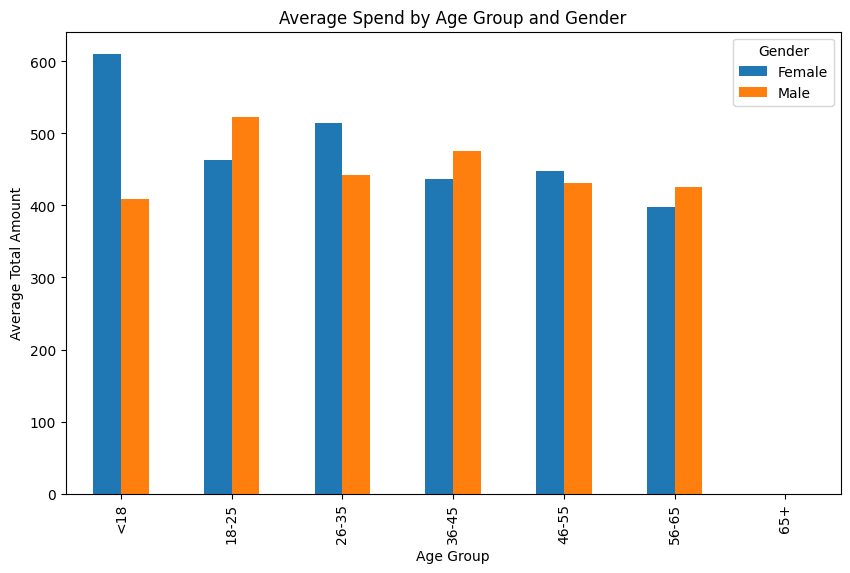

In [ ]:
avg_spend = df.groupby(['Age Group', 'Gender'])['Total Amount'].mean().unstack()
avg_spend.plot(kind='bar', figsize=(10,6), title='Average Spend by Age Group and Gender')
plt.ylabel('Average Total Amount')
plt.show()

While average spending between genders is fairly balanced across most age groups, the under-18 category shows a striking exception.Female customers in this bracket spend significantly more per transaction (₦600) than Male customers (₦410). This is a non-obvious insight, since the overall gender breakdown appeared balanced; it suggests targeted marketing or product bundling for young female customers could be a valuable, currently under-leveraged strategy.

Conclusion

Based on the exploratory analysis of the retail sales dataset, three actionable recommendations emerge:

1) Prioritize Electronics inventory and promotions. Electronics generated the highest revenue among the three product categories, closely followed by Clothing. While all three categories are fairly balanced, a modest shift in stocking priority or marketing spend toward Electronics could capture incremental revenue given its current lead.
2) Investigate and replicate the peak month sales spike. Monthly sales peaked in may 2023 and dropped to their lowest in january 2024. Understanding what drove the peak (promotion, seasonal demand, restocking) could help replicate that spike at other points in the year, while the low month should be examined for gaps in marketing or stock availability.
3) Target young female customers with tailored offers. Although overall spending is balanced across genders, customers under 18 show a notable exception Female customers in this age group spend considerably more per transaction than their Male counterparts. This underused segment presents an opportunity for targeted product bundles or marketing campaigns aimed specifically at young female shoppers.